In [13]:
import numpy as np
import matplotlib.pyplot as plt

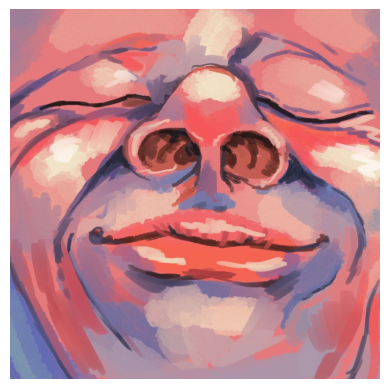

In [14]:
img_path = "image1.jpg"
img_raw = plt.imread(img_path)
plt.axis('off')
plt.imshow(img_raw)

In [15]:


def filter_image(img_raw, kernel):
    padded_img = np.pad(img_raw, ((0, img_raw.shape[0] - 1), (0, img_raw.shape[1] - 1), (0, 0)), mode='constant', constant_values=0)
    result = np.zeros_like(img_raw)
    for i in range(1, img_raw.shape[0]):
        for j in range(1, img_raw.shape[1]):
            for c in range(img_raw.shape[2]):
                sub_array = padded_img[i - 1:i - 1 + kernel.shape[0], j - 1:j - 1 + kernel.shape[1], c]
                result[i, j, c] = np.sum(sub_array * kernel)
    return result

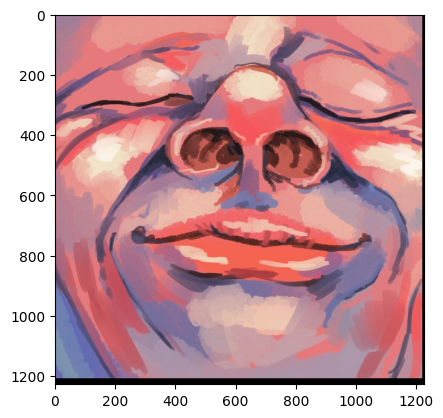

In [29]:
shifted_kernel = np.zeros((2*20+1, 2*10+1))
shifted_kernel[20, 10] = 1 
shifted = filter_image(img_raw, shifted_kernel)
plt.imshow(shifted)

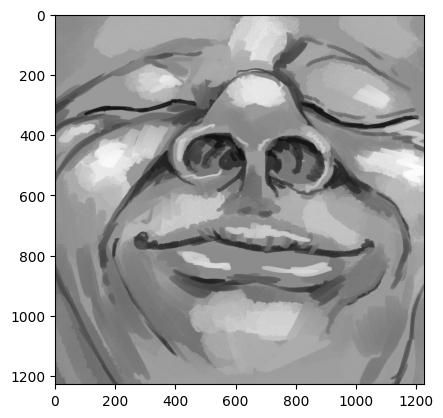

In [17]:
grayscale = 0.2989 * img_raw[:, :, 0] + 0.5870 * img_raw[:, :, 1] + 0.1140 * img_raw[:, :, 2]
plt.imshow(grayscale, cmap='gray')

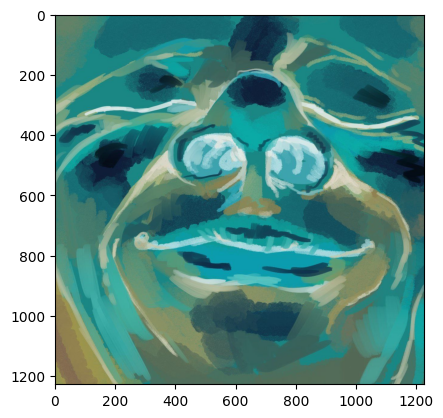

In [28]:
inverted_kernel = np.array([[-1]])
inverted = filter_image(img_raw, inverted_kernel)
plt.imshow(inverted)

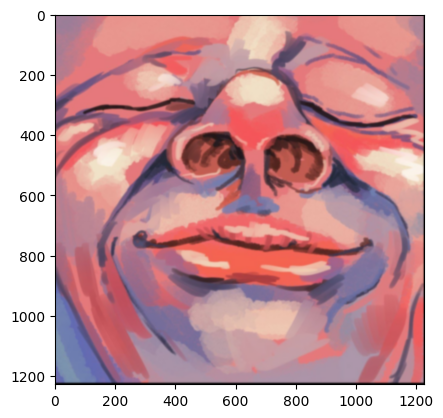

In [19]:
gaussian_blur_kernel = np.array([
    [1,  2,  4,  7,  10, 12, 10,  7,  4,  2,  1],
    [2,  4,  8,  14, 20, 24, 20, 14,  8,  4,  2],
    [4,  8,  16, 26, 36, 44, 36, 26, 16,  8,  4],
    [7,  14, 26, 42, 58, 70, 58, 42, 26, 14,  7],
    [10, 20, 36, 58, 80, 96, 80, 58, 36, 20, 10],
    [12, 24, 44, 70, 96, 115,96, 70, 44, 24, 12],
    [10, 20, 36, 58, 80, 96, 80, 58, 36, 20, 10],
    [7,  14, 26, 42, 58, 70, 58, 42, 26, 14,  7],
    [4,  8,  16, 26, 36, 44, 36, 26, 16,  8,  4],
    [2,  4,  8,  14, 20, 24, 20, 14,  8,  4,  2],
    [1,  2,  4,  7,  10, 12, 10,  7,  4,  2,  1]
])

gaussian_blur_kernel = gaussian_blur_kernel / np.sum(gaussian_blur_kernel)

gaussian_blur = filter_image(img_raw, gaussian_blur_kernel)

plt.imshow(gaussian_blur)

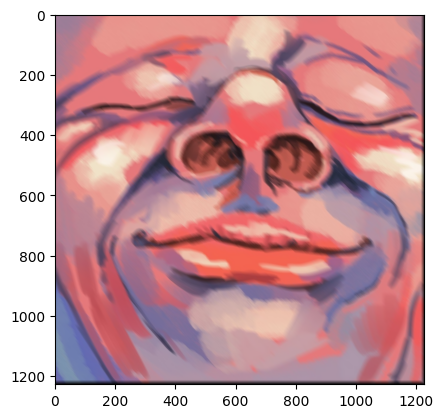

In [20]:
motion_blur_kernel = np.zeros((15, 15))
np.fill_diagonal(motion_blur_kernel, 1)
motion_blur_kernel = motion_blur_kernel / np.sum(motion_blur_kernel)

motion_blur = filter_image(img_raw, motion_blur_kernel)

plt.imshow(motion_blur)

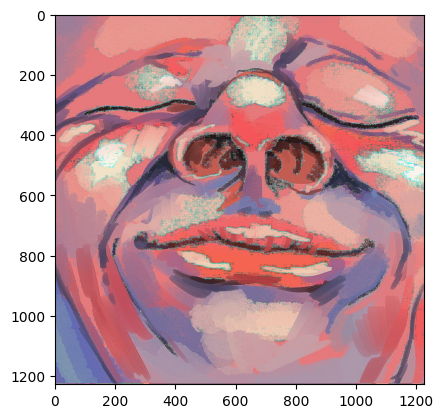

In [21]:
sharpness_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
    ])

sharpened = filter_image(img_raw, sharpness_kernel)
plt.imshow(sharpened)

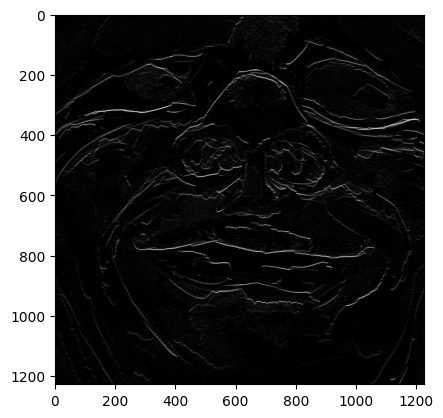

In [22]:
sobel_y_kernel = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
    ])

grayscale_3d = np.expand_dims(grayscale, axis=2)
sobel_y = filter_image(grayscale_3d, sobel_y_kernel)
sobel_y = np.clip(sobel_y, 0, 255)
plt.imshow(sobel_y.squeeze(), cmap='gray')

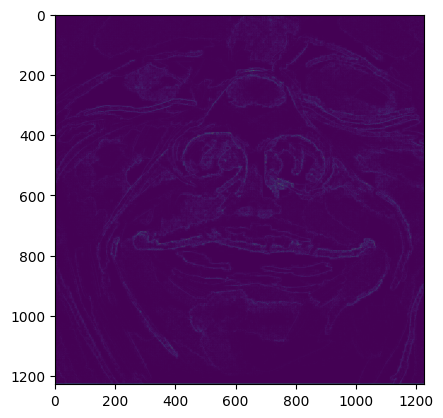

In [23]:
edge_detection_kernel = np.array([
    [0, -1, 0], 
    [-1, 4, -1],
    [0, -1, 0]
    ])


edge_detected = filter_image(grayscale_3d, edge_detection_kernel)
edge_detected = np.clip(edge_detected, 0, 255)
plt.imshow(edge_detected)

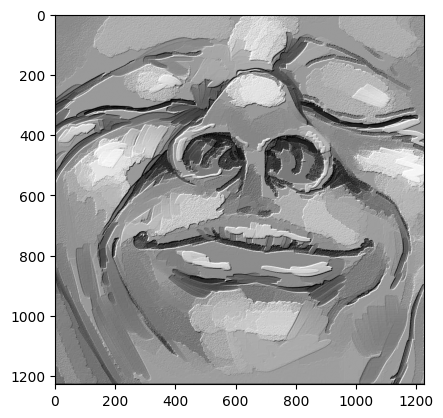

In [25]:
emboss_kernel = np.array([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2]
    ])

embossed = filter_image(grayscale_3d, emboss_kernel)
embossed = np.clip(embossed, 0, 255)
plt.imshow(embossed, cmap='gray')